In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tilt.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_AE = df_eddies[df_eddies.Cyc=='AE'].copy().dropna()
df_CE = df_eddies[df_eddies.Cyc=='CE'].copy().dropna()
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.123684,118.032741,47.992205,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.022306,108.004573,52.019741,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,0.765331,109.827647,54.305771,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,0.871468,111.650721,56.591801,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976111,184.917110
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,0.945071,115.925719,57.471319,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.065523,181.172847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,0.903800,57.890310,10.534469,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,23.512541,69.098943
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,1.216728,61.813856,10.733594,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,20.463430,69.913173
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,1.267517,65.737402,10.932719,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,1.276832,69.660948,11.131844,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [4]:
df_TDis_ave = pd.DataFrame(columns=['Eddy', 'Cyc', 'ave_TDis', 'min_TDis', 'max_TDis'])
for eddy in df_eddies.Eddy.unique():
    df = df_eddies[df_eddies.Eddy==eddy].copy().dropna()
    if len(df) >= 30:
        df_TDis_ave.loc[len(df_TDis_ave)] = {'Eddy': eddy, 'Cyc': df.iloc[0].Cyc, 'ave_TDis': df.TiltDis.mean(),
                                            'min_TDis': df.TiltDis.min(), 'max_TDis': df.TiltDis.max()}
df_TDis_ave = df_TDis_ave.dropna()
df_TDis_ave_AE = df_TDis_ave[df_TDis_ave.Cyc=='AE']
df_TDis_ave_CE = df_TDis_ave[df_TDis_ave.Cyc=='CE']
df_TDis_ave


,Eddy,Cyc,ave_TDis,min_TDis,max_TDis
0,1,CE,42.963331,8.021454,151.164797
1,2,CE,18.260336,6.270750,35.734016
2,3,AE,51.225285,19.955935,110.163000
3,4,AE,27.618340,2.660480,68.538360
4,5,AE,21.133776,5.271150,39.088252
...,...,...,...,...,...
1438,3826,CE,5.269290,1.691253,11.000575
1439,3828,CE,10.679458,0.032074,50.686258
1440,3831,AE,10.692770,5.072790,26.061448
1441,3835,AE,14.387857,2.142920,42.847348


In [5]:
def circular_mean_deg_true_north(deg):
    deg = np.asarray(deg)
    r = np.deg2rad(deg)
    C = np.mean(np.cos(r))
    S = np.mean(np.sin(r))
    return np.rad2deg(np.arctan2(S, C)) % 360 

df_TDir_ave = pd.DataFrame(columns=['Eddy', 'Cyc', 'ave_TDir'])
for eddy in df_eddies.Eddy.unique():
    df = df_eddies[df_eddies.Eddy==eddy].copy().dropna()
    if len(df) >= 30:
        df_TDir_ave.loc[len(df_TDir_ave)] = {'Eddy': eddy, 'Cyc': df.iloc[0].Cyc, 'ave_TDir': circular_mean_deg_true_north(df.TiltDir)}
df_TDir_ave = df_TDir_ave.dropna()
df_TDir_ave_AE = df_TDir_ave[df_TDir_ave.Cyc=='AE']
df_TDir_ave_CE = df_TDir_ave[df_TDir_ave.Cyc=='CE']
df_TDir_ave


,Eddy,Cyc,ave_TDir
0,1,CE,119.991934
1,2,CE,147.642512
2,3,AE,331.484524
3,4,AE,13.755621
4,5,AE,32.834006
...,...,...,...
1438,3826,CE,146.663612
1439,3828,CE,241.468316
1440,3831,AE,124.204905
1441,3835,AE,28.933693


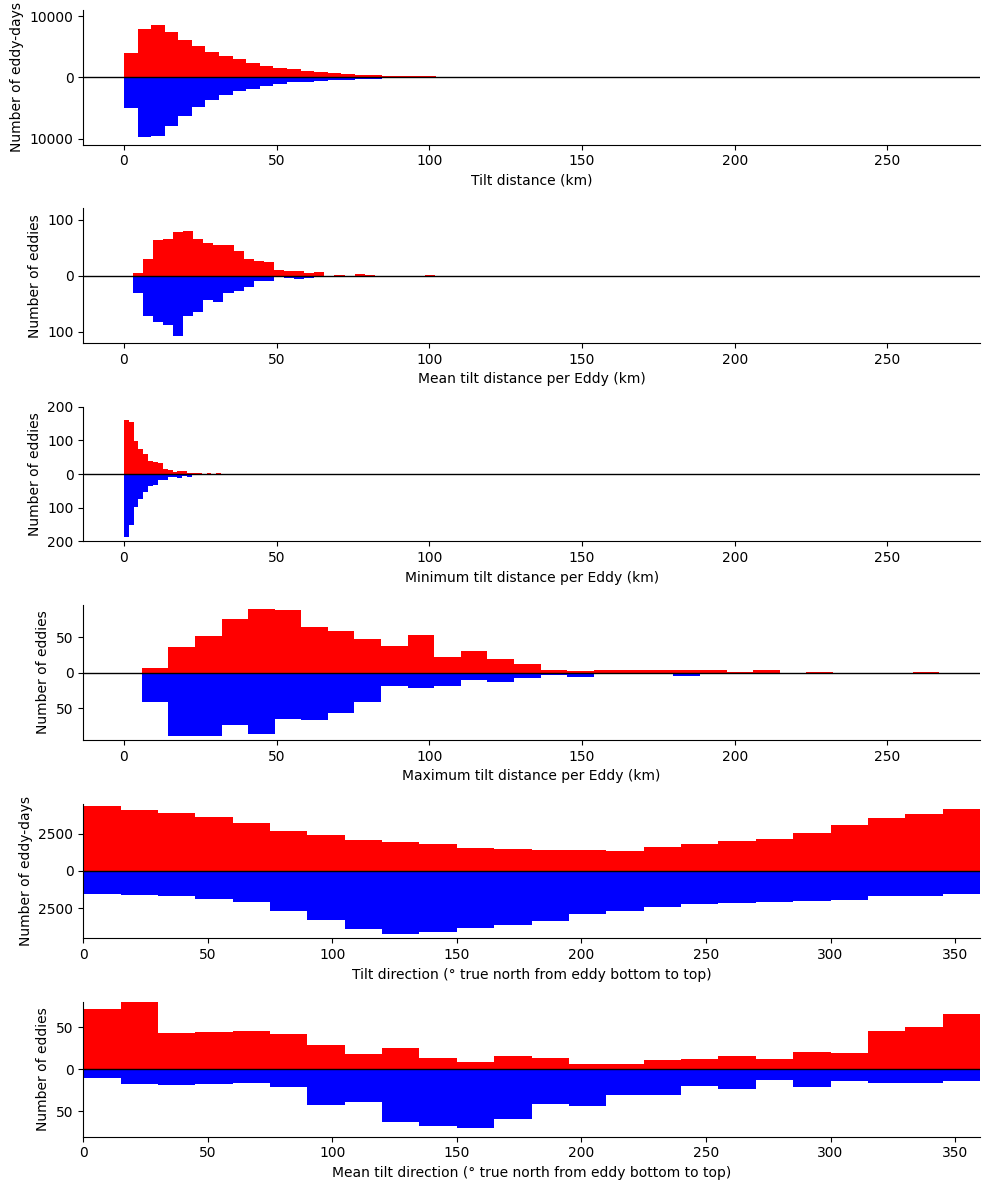

In [6]:
fig, axs = plt.subplots(6, 1, figsize=(10, 12))

def clean(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return a[np.isfinite(a)], b[np.isfinite(b)]

def shared_bins(a, b, method='fd', min_bins=12, max_bins=40):
    a, b = clean(a, b)
    all_vals = np.concatenate([a, b])
    edges = np.histogram_bin_edges(all_vals, bins=method)
    
    n_bins = len(edges) - 1
    if n_bins < min_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), min_bins + 1)
    elif n_bins > max_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), max_bins + 1)
    return edges

def mirrored_hist(ax, ae, ce, bins, xlabel, ylabel, ylim=None, xlim=None):
    ae, ce = clean(ae, ce)
    
    ax.hist(ae, bins=bins, color='r')
    counts, edges = np.histogram(ce, bins=bins)
    ax.bar(edges[:-1], -counts, width=np.diff(edges), color='b', align='edge')
    
    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([abs(int(t)) for t in ax.get_yticks()])
    
    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None:
        ax.set_xlim(xlim)

# --- Plot 0 ---
bins0 = shared_bins(df_AE.TiltDis, df_CE.TiltDis, method='fd', min_bins=20, max_bins=60)
mirrored_hist(
    axs[0],
    df_AE.TiltDis,
    df_CE.TiltDis,
    bins0,
    'Tilt distance (km)',
    'Number of eddy-days',
    ylim=(-11000, 11000)
)

# --- Plot 1 ---
bins1 = shared_bins(df_TDis_ave_AE.ave_TDis, df_TDis_ave_CE.ave_TDis, method='fd', min_bins=12, max_bins=30)
mirrored_hist(
    axs[1],
    df_TDis_ave_AE.ave_TDis,
    df_TDis_ave_CE.ave_TDis,
    bins1,
    'Mean tilt distance per Eddy (km)',
    'Number of eddies',
    ylim=(-120, 120),
    xlim=axs[0].get_xlim()
)

# --- Plot 2 ---
bins2 = shared_bins(df_TDis_ave_AE.min_TDis, df_TDis_ave_CE.min_TDis, method='fd', min_bins=12, max_bins=30)
mirrored_hist(
    axs[2],
    df_TDis_ave_AE.min_TDis,
    df_TDis_ave_CE.min_TDis,
    bins2,
    'Minimum tilt distance per Eddy (km)',
    'Number of eddies',
    ylim=(-200, 200),
    xlim=axs[0].get_xlim()
)

# --- Plot 3 ---
bins3 = shared_bins(df_TDis_ave_AE.max_TDis, df_TDis_ave_CE.max_TDis, method='fd', min_bins=12, max_bins=30)
mirrored_hist(
    axs[3],
    df_TDis_ave_AE.max_TDis,
    df_TDis_ave_CE.max_TDis,
    bins3,
    'Maximum tilt distance per Eddy (km)',
    'Number of eddies',
    ylim=(-95, 95),
    xlim=axs[0].get_xlim()
)

# --- Plot 4 ---
# For direction, fixed bins are better than "optimised" bins because the variable is angular
bins4 = np.arange(0, 361, 15)
mirrored_hist(
    axs[4],
    df_AE.TiltDir % 360,
    df_CE.TiltDir % 360,
    bins4,
    'Tilt direction (° true north from eddy bottom to top)',
    'Number of eddy-days',
    ylim=(-4500, 4500),
    xlim=(0, 360)
)

# --- Plot 5 ---
bins5 = np.arange(0, 361, 15)
mirrored_hist(
    axs[5],
    df_TDir_ave_AE.ave_TDir % 360,
    df_TDir_ave_CE.ave_TDir % 360,
    bins5,
    'Mean tilt direction (° true north from eddy bottom to top)',
    'Number of eddies',
    ylim=(-80, 80),
    xlim=(0, 360)
)

plt.tight_layout()
plt.show()
